# Desafio FIAP Software Security

O objetivo deste projeto é utilizar Inteligência Artificial para analisar diagramas de arquitetura de software e gerar um relatório de possíveis ameaças baseado na metodologia STRIDE, mapeando vulnerabilidades e sugerindo contramedidas específicas para cada componente. Dessa forma, será possível otimizar a análise de segurança e proteger os sistemas criados por arquitetos e desenvolvedores.

Equipe:
1. Iêsa Lobato
2. Ismael Costa
3. Felipe Vieira
4. Rilson Soares

1. Bibliotecas

In [ ]:
!pip install ultralytics -q

import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

2. Dataset

Imagens foram anotadas na **Plataforma Roboflow**
- frontend
- database
- app_service
- auth_service
- messaging
- api_gateway


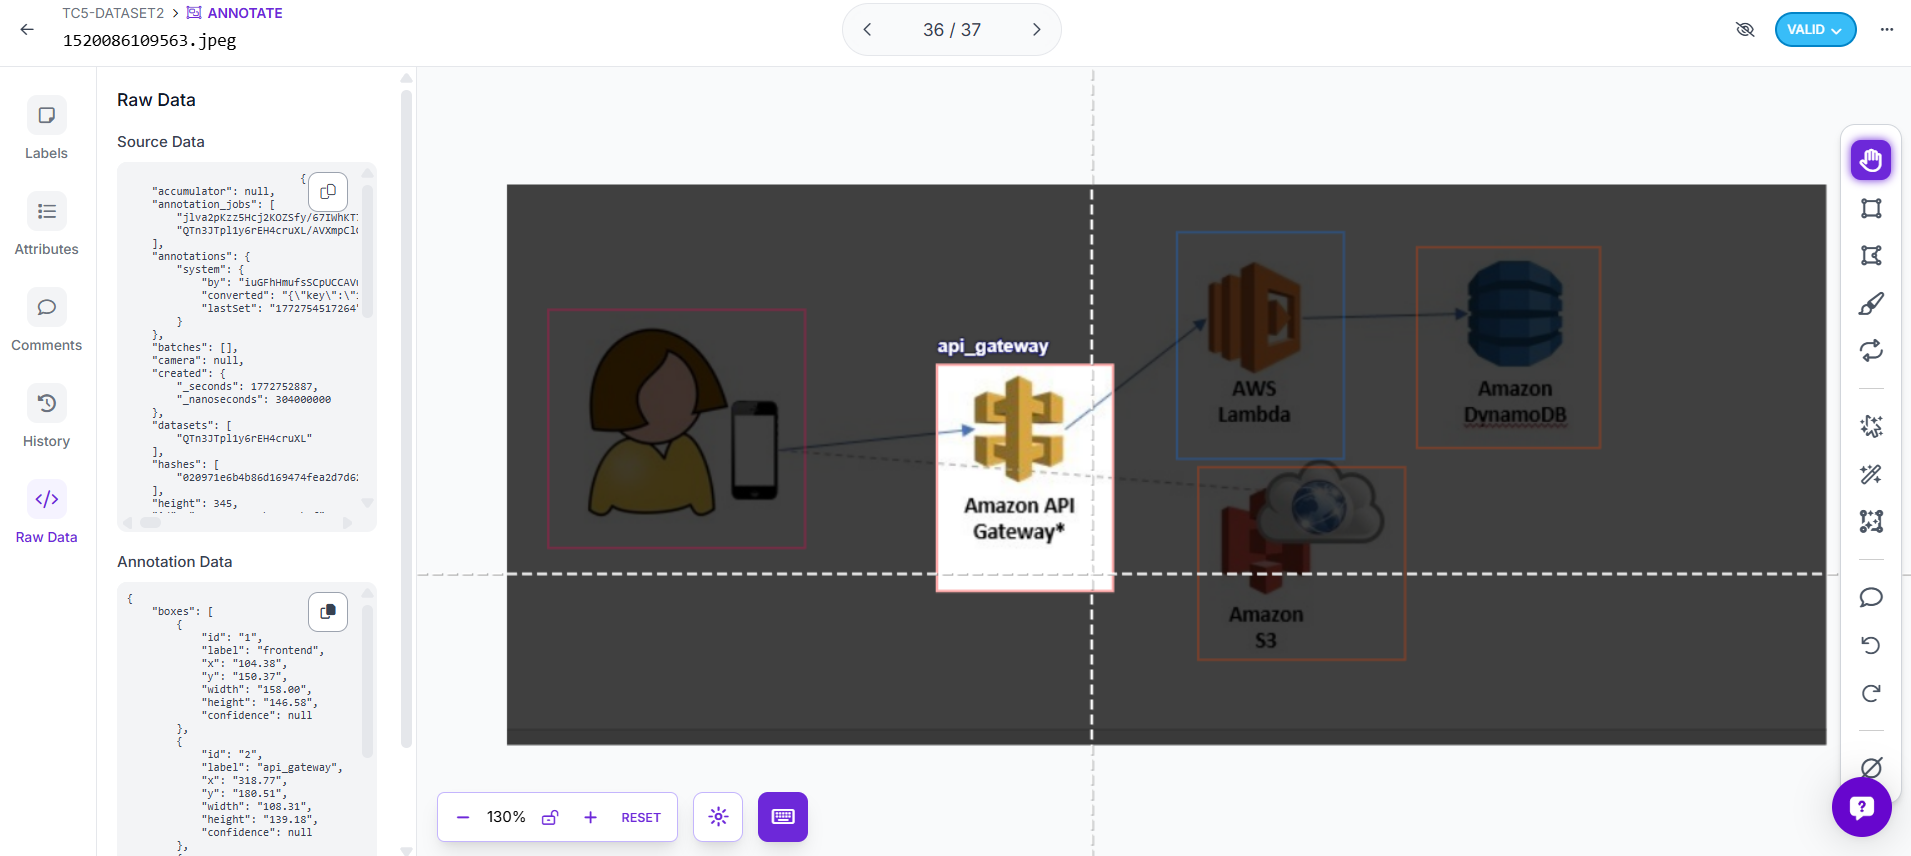

In [ ]:
import zipfile
import os

caminho_do_zip = '/content/dataset.zip'
pasta_destino = '/content/dataset_arquitetura'
with zipfile.ZipFile(caminho_do_zip, 'r') as zip_ref:
    zip_ref.extractall(pasta_destino)

print("***** DATASET PRONTO *****")

***** DATASET PRONTO *****


3.  Treinamento

In [ ]:
from ultralytics import YOLO

caminho_yaml = '/content/dataset_arquitetura/data.yaml'
modelo = YOLO('yolov8n.pt')

print("***** Treinamento iniciado *****")
resultados = modelo.train(data=caminho_yaml, epochs=500, imgsz=640, plots=True)
print("***** Treinamento finalizado *****")

***** Treinamento iniciado *****
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_arquitetura/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=500, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

4. Inferência

Saving 1663342617142.png to 1663342617142 (2).png
***** Inferência iniciada: 1663342617142 (2).png *****

image 1/1 /content/1663342617142 (2).png: 576x640 8 api_gateways, 1 app_service, 8 databases, 3 frontends, 2 messagings, 8.0ms
Speed: 2.8ms preprocess, 8.0ms inference, 1.3ms postprocess per image at shape (1, 3, 576, 640)
***** Inferência finalizada *****
Componentes encontrados:
- database
- api_gateway
- app_service
- frontend
- messaging


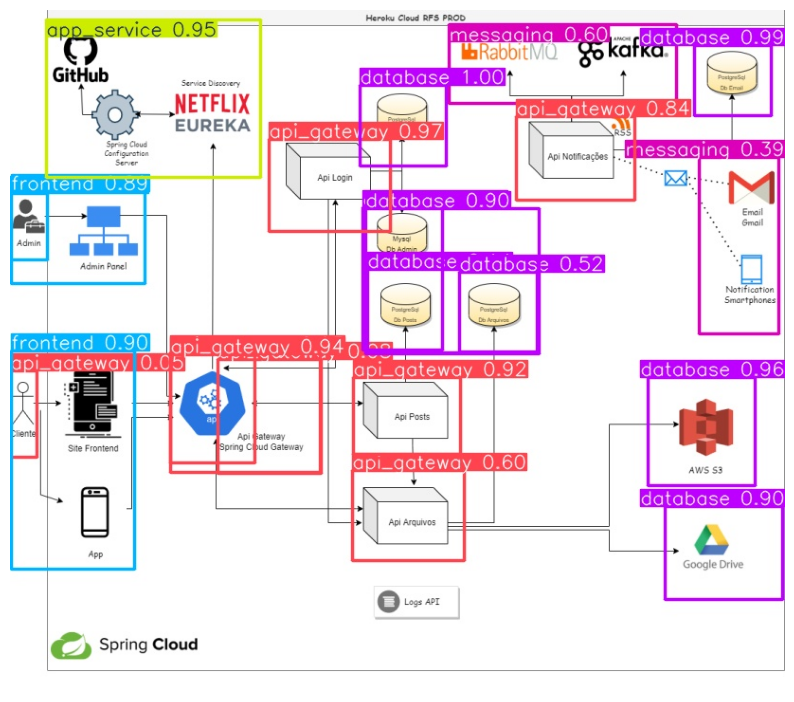

In [ ]:
import os
import glob
from ultralytics import YOLO
from google.colab import files
import cv2
import matplotlib.pyplot as plt

def detectar_componentes(caminho_imagem):
    # consulta caminho do melhor treino
    pastas_treino = glob.glob('runs/detect/train*')

    if not pastas_treino:
        print("!!! Erro: Nenhuma pasta de treinamento encontrada.")
        return []

    pasta_mais_recente = max(pastas_treino, key=os.path.getmtime)
    caminho_modelo_treinado = f'{pasta_mais_recente}/weights/best.pt'

    componentes_encontrados = []

    if os.path.exists(caminho_modelo_treinado):
        modelo = YOLO(caminho_modelo_treinado)
        resultados = modelo(caminho_imagem, conf=0.05)

        for resultado in resultados:
            for box in resultado.boxes:
                id_classe = int(box.cls[0])
                nome_classe = modelo.names[id_classe]
                if nome_classe not in componentes_encontrados:
                    componentes_encontrados.append(nome_classe)

        # salva a imagem com os quadrados desenhados
        resultado.save(filename="resultado_inferencia.jpg")

    else:
        print(f"!!! Erro: treino best.pt não encontrado na pasta {pasta_mais_recente}.")

    return componentes_encontrados

# upload da imagem a ser analisada
imagem_carregada = files.upload()

if len(imagem_carregada) > 0:
    nome_ficheiro = list(imagem_carregada.keys())[0]

    print(f"***** Inferência iniciada: {nome_ficheiro} *****")
    componentes_detectados = detectar_componentes(nome_ficheiro)
    print("***** Inferência finalizada *****")

    print("Componentes encontrados:")
    if len(componentes_detectados) > 0:
        for comp in componentes_detectados:
            print(f"- {comp}")
    else:
        print("!!! Nenhum componente detetado nesta imagem.")

    # exibir imagem após análise com os quadrados
    if os.path.exists("resultado_inferencia.jpg"):
        img_resultado = cv2.imread("resultado_inferencia.jpg")
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

else:
    print("Nenhuma imagem foi selecionada.")

6. Relatório

In [ ]:
import pandas as pd
from IPython.display import display

base_conhecimento_stride = {
    'frontend': [
        {"Categoria": "Spoofing", "Ameaça": "Roubo de sessão ou falsificação de identidade do cliente", "Contramedida": "Exigir HTTPS estrito e proteger cookies (HttpOnly, Secure)"}
    ],
    'api_gateway': [
        {"Categoria": "Denial of Service", "Ameaça": "Sobrecarga de requisições na API (DDoS)", "Contramedida": "Configurar Rate Limiting (limite de requisições) e WAF"},
        {"Categoria": "Information Disclosure", "Ameaça": "Exposição de endpoints ou dados sensíveis na resposta", "Contramedida": "Filtrar respostas e utilizar tokens opacos"}
    ],
    'auth_service': [
        {"Categoria": "Elevation of Privilege", "Ameaça": "Atacante escalar permissões burlando o login", "Contramedida": "Implementar RBAC (Role-Based Access Control) e MFA obrigatoriamente"}
    ],
    'app_service': [
        {"Categoria": "Tampering", "Ameaça": "Injeção de código (SQLi, XSS) via microserviço", "Contramedida": "Validação rigorosa de todos os inputs recebidos de outros serviços"},
        {"Categoria": "Repudiation", "Ameaça": "Incapacidade de provar qual microserviço falhou ou foi atacado", "Contramedida": "Implementar rastreabilidade centralizada (Distributed Tracing)"}
    ],
    'database': [
        {"Categoria": "Information Disclosure", "Ameaça": "Vazamento em massa da base de dados", "Contramedida": "Criptografia forte em repouso (Data at Rest) e isolamento de rede (VPC privada)"},
        {"Categoria": "Tampering", "Ameaça": "Alteração indevida de registos", "Contramedida": "Backups automatizados e imutáveis com retenção estrita"}
    ],
    'messaging': [
        {"Categoria": "Tampering", "Ameaça": "Interceção e alteração de mensagens na fila", "Contramedida": "Criptografia TLS em trânsito e assinatura digital de mensagens"}
    ]
}

def gerar_relatorio_stride(lista_componentes):
    linhas_relatorio = []

    for componente in lista_componentes:
        if componente in base_conhecimento_stride:
            ameacas = base_conhecimento_stride[componente]
            for ameaca in ameacas:
                linhas_relatorio.append({
                    "Componente Detectado": componente,
                    "Categoria STRIDE": ameaca["Categoria"],
                    "Descrição da Ameaça": ameaca["Ameaça"],
                    "Contramedida Recomendada": ameaca["Contramedida"]
                })
        else:
             linhas_relatorio.append({
                    "Componente Detectado": componente,
                    "Categoria STRIDE": "N/A",
                    "Descrição da Ameaça": "Componente não mapeado na base de conhecimento",
                    "Contramedida Recomendada": "Análise manual necessária"
                })

    tabela_df = pd.DataFrame(linhas_relatorio)
    return tabela_df

relatorio_final = gerar_relatorio_stride(componentes_detectados)

print("***** RELATÓRIO DE AMEAÇAS *****")
display(relatorio_final)


***** RELATÓRIO DE AMEAÇAS *****


,Componente Detectado,Categoria STRIDE,Descrição da Ameaça,Contramedida Recomendada
0,database,Information Disclosure,Vazamento em massa da base de dados,Criptografia forte em repouso (Data at Rest) e...
1,database,Tampering,Alteração indevida de registos,Backups automatizados e imutáveis com retenção...
2,api_gateway,Denial of Service,Sobrecarga de requisições na API (DDoS),Configurar Rate Limiting (limite de requisiçõe...
3,api_gateway,Information Disclosure,Exposição de endpoints ou dados sensíveis na r...,Filtrar respostas e utilizar tokens opacos
4,app_service,Tampering,"Injeção de código (SQLi, XSS) via microserviço",Validação rigorosa de todos os inputs recebido...
5,app_service,Repudiation,Incapacidade de provar qual microserviço falho...,Implementar rastreabilidade centralizada (Dist...
6,frontend,Spoofing,Roubo de sessão ou falsificação de identidade ...,Exigir HTTPS estrito e proteger cookies (HttpO...
7,messaging,Tampering,Interceção e alteração de mensagens na fila,Criptografia TLS em trânsito e assinatura digi...
